# 02 — Anomaly Detection: CMAPSS FD001

**Dataset:** NASA CMAPSS FD001 — 100 engines run to failure  
**Train:** 20,631 rows | **Test:** 13,096 rows | **Sensors:** 21 (14 useful, 7 constant dropped)  

**Label strategy:**
- RUL > 30 cycles → **Normal** (85.0%)
- RUL ≤ 30 cycles → **Anomaly** (15.0%)

**Outputs:**
- `edge/ai/models/isolation_forest.pkl`
- `edge/ai/models/scaler.pkl`
- `edge/ai/models/features.pkl`
- `edge/ai/models/model_metadata.pkl`

## 1. Imports & Config

In [29]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_fscore_support
)
plt.style.use('seaborn-v0_8')
RANDOM_STATE  = 42
MODEL_DIR     = '../edge/ai/models'
DATA_DIR      = '../dataset'
ANOMALY_THRESHOLD = 30

os.makedirs(MODEL_DIR, exist_ok=True)

# ── Sensor name mapping (s1-s21 → physical names) ──
SENSOR_NAMES = {
    's1' : 'T2',      # Total temp — fan inlet         [CONSTANT - dropped]
    's2' : 'T24',     # Total temp — LPC outlet
    's3' : 'T30',     # Total temp — HPC outlet
    's4' : 'T50',     # Total temp — LPT outlet
    's5' : 'P2',      # Pressure — fan inlet            [CONSTANT - dropped]
    's6' : 'P15',     # Total pressure — bypass duct    [CONSTANT - dropped]
    's7' : 'P30',     # Total pressure — HPC outlet
    's8' : 'Nf',      # Physical fan speed
    's9' : 'Nc',      # Physical core speed
    's10': 'Epr',     # Engine pressure ratio           [CONSTANT - dropped]
    's11': 'Ps30',    # Static pressure — HPC outlet
    's12': 'Phi',     # Fuel flow ratio to Ps30
    's13': 'NRf',     # Corrected fan speed
    's14': 'NRc',     # Corrected core speed
    's15': 'BPR',     # Bypass ratio
    's16': 'farB',    # Burner fuel-air ratio           [CONSTANT - dropped]
    's17': 'htBleed', # Bleed enthalpy
    's18': 'Nf_dmd',  # Demanded fan speed              [CONSTANT - dropped]
    's19': 'PCNfR',   # Demanded corrected fan speed    [CONSTANT - dropped]
    's20': 'W31',     # HPT coolant bleed
    's21': 'W32',     # LPT coolant bleed
}

# ── Column names using physical sensor names ──

# ── Update sensor lists to use physical names ──
CONSTANT_SENSORS = ['T2', 'P2', 'P15', 'Epr', 'farB', 'Nf_dmd', 'PCNfR']
GOOD_SENSORS     = ['T24','T30','T50','P30','Nf','Nc','Ps30','Phi','NRf','NRc','BPR','htBleed','W31','W32']

print('Imports OK')
print(f'Anomaly threshold : RUL <= {ANOMALY_THRESHOLD} cycles')
print(f'Useful sensors    : {GOOD_SENSORS}')
print(f'Dropped sensors   : {CONSTANT_SENSORS}')

Imports OK
Anomaly threshold : RUL <= 30 cycles
Useful sensors    : ['T24', 'T30', 'T50', 'P30', 'Nf', 'Nc', 'Ps30', 'Phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']
Dropped sensors   : ['T2', 'P2', 'P15', 'Epr', 'farB', 'Nf_dmd', 'PCNfR']


## 2. Load & Label Data

In [30]:
COLS = [
    'engine_id', 'cycle',
    'op1', 'op2', 'op3',
    'T2','T24','T30','T50','P2','P15','P30',
    'Nf','Nc','Epr','Ps30','Phi','NRf','NRc',
    'BPR','farB','htBleed','Nf_dmd','PCNfR','W31','W32'
]


def load_and_label(path, rul_path=None):
    df = pd.read_csv(path, sep=' ', header=None).dropna(axis=1)
    df.columns = COLS

    if rul_path:
        # Test set: RUL at final cycle is provided — build backwards
        rul_final = pd.read_csv(rul_path, header=None, names=['rul_final'])
        rul_final['engine_id'] = rul_final.index + 1
        max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
        max_cycles.columns = ['engine_id', 'max_cycle']
        df = df.merge(max_cycles, on='engine_id').merge(rul_final, on='engine_id')
        df['rul'] = df['rul_final'] + (df['max_cycle'] - df['cycle'])
        df.drop(columns=['max_cycle', 'rul_final'], inplace=True)
    else:
        # Train set: engines ran to failure — RUL = cycles left until breakdown
        max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
        max_cycles.columns = ['engine_id', 'max_cycle']
        df = df.merge(max_cycles, on='engine_id')
        df['rul'] = df['max_cycle'] - df['cycle']
        df.drop(columns=['max_cycle'], inplace=True)

    CLIP_RUL = 125
    df['rul'] = df['rul'].clip(upper=CLIP_RUL)

    # 1 = anomaly (engine failing soon), 0 = normal (engine healthy)
    df['label'] = (df['rul'] <= ANOMALY_THRESHOLD).astype(int)
    return df

train = load_and_label(f'{DATA_DIR}/train_FD001.txt')
test  = load_and_label(f'{DATA_DIR}/test_FD001.txt', rul_path=f'{DATA_DIR}/RUL_FD001.txt')

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
print()
for name, df_ in [('Train', train), ('Test', test)]:
    lc = df_['label'].value_counts().sort_index()
    print(f'{name} labels:')
    print(f'  Normal  (0): {lc[0]:6d} ({lc[0]/len(df_)*100:.1f}%)')
    print(f'  Anomaly (1): {lc[1]:6d} ({lc[1]/len(df_)*100:.1f}%)')
    print()
train.head(3)

Train shape : (20631, 28)
Test  shape : (13096, 28)

Train labels:
  Normal  (0):  17531 (85.0%)
  Anomaly (1):   3100 (15.0%)

Test labels:
  Normal  (0):  12764 (97.5%)
  Anomaly (1):    332 (2.5%)



,engine_id,cycle,op1,op2,op3,T2,T24,T30,T50,P2,...,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR,W31,W32,rul,label
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125,0


## 3. Verify Labels — Visualise RUL Distribution

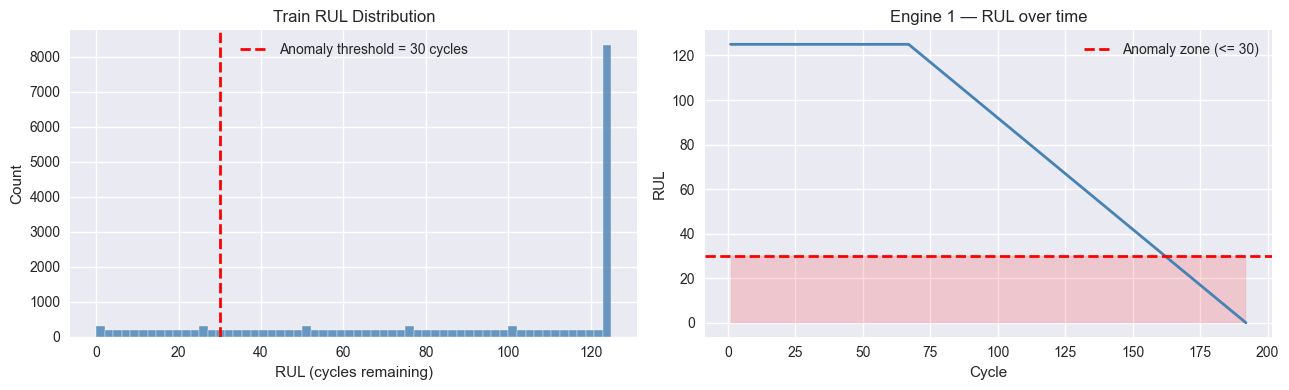

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train['rul'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(ANOMALY_THRESHOLD, color='red', linestyle='--', lw=2,
                label=f'Anomaly threshold = {ANOMALY_THRESHOLD} cycles')
axes[0].set_xlabel('RUL (cycles remaining)')
axes[0].set_ylabel('Count')
axes[0].set_title('Train RUL Distribution')
axes[0].legend()

# Show a single engine degrading over time
sample_engine = train[train['engine_id'] == 1]
axes[1].plot(sample_engine['cycle'], sample_engine['rul'], color='steelblue', lw=2)
axes[1].axhline(ANOMALY_THRESHOLD, color='red', linestyle='--', lw=2,
                label=f'Anomaly zone (<= {ANOMALY_THRESHOLD})')
axes[1].fill_between(sample_engine['cycle'],
                     0, ANOMALY_THRESHOLD, alpha=0.15, color='red')
axes[1].set_xlabel('Cycle'); axes[1].set_ylabel('RUL')
axes[1].set_title('Engine 1 — RUL over time')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'rul_distribution.png'), dpi=120)
plt.show()

## 4. Feature Engineering

In [32]:
def engineer_features(df):
    dfs = []
    for eid in df['engine_id'].unique():
        e = df[df['engine_id'] == eid].copy()

        # Rolling window captures local trend
        for s in GOOD_SENSORS:
            e[f'{s}_roll_mean'] = e[s].rolling(window=15).mean()
            e[f'{s}_roll_std']  = e[s].rolling(window=15).std()
            e[f'{s}_roc']       = e[s].diff()
            engine_mean = e[s].mean()
            engine_std  = e[s].std() + 1e-8   # avoid divide by zero
            e[f'{s}_zscore'] = (e[s] - engine_mean) / engine_std

            # ← NEW: deviation from THIS engine's own early baseline
            baseline = e[s].head(20).mean()   # first 20 cycles = healthy baseline
            e[f'{s}_dev'] = e[s] - baseline   # how far has it drifted?

        # ← NEW: engine age as a feature
        e['cycle_norm'] = e['cycle'] / e['cycle'].max()

        dfs.append(e)
    return pd.concat(dfs).dropna().reset_index(drop=True)
print('Engineering features for train...')
train = engineer_features(train)
print(f'  Train: {train.shape}')

print('Engineering features for test...')
test = engineer_features(test)
print(f'  Test : {test.shape}')

Engineering features for train...
  Train: (19231, 99)
Engineering features for test...
  Test : (11696, 99)


## 5. Build Feature Matrix

In [33]:
FEATURES = (
    GOOD_SENSORS +
    [f'{s}_roll_mean' for s in GOOD_SENSORS] +
    [f'{s}_roll_std'  for s in GOOD_SENSORS] +
    [f'{s}_roc'       for s in GOOD_SENSORS] +
    [f'{s}_dev'       for s in GOOD_SENSORS] +
    ['cycle_norm']
)


missing = [f for f in FEATURES if f not in train.columns]
if missing:
    raise ValueError(f'Missing features: {missing}')

X_train = train[FEATURES]
y_train = train['label']
X_test  = test[FEATURES]
y_test  = test['label']

print(f'Total features  : {len(FEATURES)}')
print(f'  14 raw sensors + 14 roll_mean + 14 roll_std + 14 roc = 56')
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print()
print(f'Train — Normal: {(y_train==0).sum()}  Anomaly: {(y_train==1).sum()}')
print(f'Test  — Normal: {(y_test==0).sum()}   Anomaly: {(y_test==1).sum()}')

Total features  : 71
  14 raw sensors + 14 roll_mean + 14 roll_std + 14 roc = 56
X_train : (19231, 71)
X_test  : (11696, 71)

Train — Normal: 16131  Anomaly: 3100
Test  — Normal: 11364   Anomaly: 332


## 6. Scale Features

In [34]:
# Fit ONLY on train — never on test (would be data leakage)
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

scaler_path = os.path.join(MODEL_DIR, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Scaler saved -> {scaler_path}')

Scaler saved -> ../edge/ai/models\scaler.pkl


## 7. Contamination Sweep

  c=0.05  P=1.000  R=0.024  F1=0.047  flagged=8
  c=0.08  P=0.822  R=0.181  F1=0.296  flagged=73
  c=0.10  P=0.609  R=0.295  F1=0.398  flagged=161
  c=0.12  P=0.461  R=0.377  F1=0.415  flagged=271
  c=0.15  P=0.342  R=0.494  F1=0.404  flagged=479
  c=0.18  P=0.273  R=0.611  F1=0.378  flagged=743
  c=0.20  P=0.238  R=0.699  F1=0.355  flagged=976
  c=0.25  P=0.176  R=0.783  F1=0.288  flagged=1475

Best contamination = 0.12  (F1=0.415)


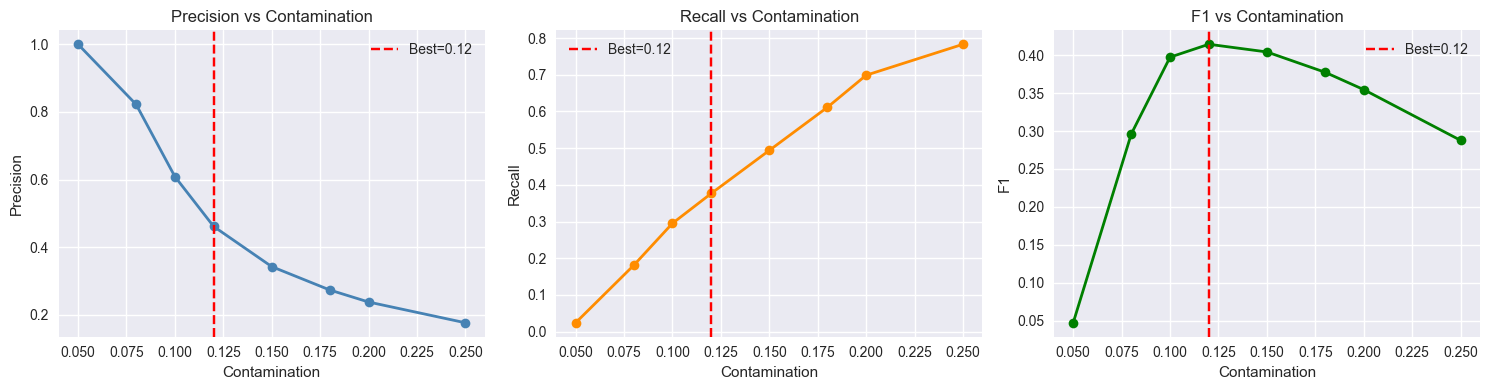

In [35]:
# Anomaly rate in train = 15% so sweep around that
CONTAMINATION_VALUES = [0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25]

results = []
for c in CONTAMINATION_VALUES:
    clf    = IsolationForest(contamination=c, n_estimators=200,
                             random_state=RANDOM_STATE, n_jobs=-1)
    clf.fit(X_train_scaled)              # train on TRAIN
    preds  = clf.predict(X_test_scaled)  # evaluate on TEST
    y_pred = (preds == -1).astype(int)

    p, r, f, _ = precision_recall_fscore_support(
        y_test, y_pred, average='binary', zero_division=0
    )
    results.append({'contamination': c, 'precision': p,
                    'recall': r, 'f1': f, 'flagged': y_pred.sum()})
    print(f'  c={c:.2f}  P={p:.3f}  R={r:.3f}  F1={f:.3f}  flagged={y_pred.sum()}')

results_df = pd.DataFrame(results)
best_row           = results_df.loc[results_df['f1'].idxmax()]
BEST_CONTAMINATION = best_row['contamination']
print(f'\nBest contamination = {BEST_CONTAMINATION}  (F1={best_row["f1"]:.3f})')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['precision','recall','f1'],
                          ['steelblue','darkorange','green']):
    ax.plot(results_df['contamination'], results_df[col], 'o-', color=color, lw=2)
    ax.axvline(BEST_CONTAMINATION, color='red', linestyle='--',
               label=f'Best={BEST_CONTAMINATION}')
    ax.set_xlabel('Contamination'); ax.set_ylabel(col.capitalize())
    ax.set_title(f'{col.capitalize()} vs Contamination'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'contamination_sweep.png'), dpi=120)
plt.show()

## 8. Train Final Model

In [36]:
model = IsolationForest(
    contamination = BEST_CONTAMINATION,
    n_estimators  = 300,
    max_samples   = 'auto',
    random_state  = RANDOM_STATE,
    n_jobs        = -1
)
model.fit(X_train_scaled)
scores_test = model.decision_function(X_test_scaled)
print(f'Model trained.')
print(f'Score range on test: {scores_test.min():.4f} to {scores_test.max():.4f}')

Model trained.
Score range on test: -0.0809 to 0.1031


## 9. Tune Decision Threshold (target Recall >= 0.70)

Found threshold with Recall >= 0.70

Best threshold : 0.0222  (pct=9.0%)
Precision      : 0.2242
Recall         : 0.7078
F1             : 0.3406


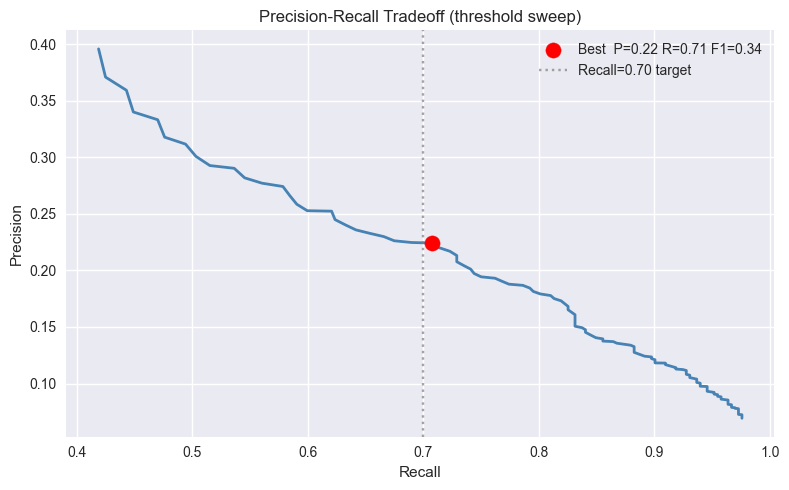

In [37]:
thresh_results = []
for pct in np.linspace(3, 40, 150):
    thresh     = np.percentile(scores_test, pct)
    y_pred_t   = (scores_test < thresh).astype(int)
    p, r, f, _ = precision_recall_fscore_support(
        y_test, y_pred_t, average='binary', zero_division=0
    )
    thresh_results.append({'thresh': thresh, 'pct': pct,
                           'precision': p, 'recall': r, 'f1': f})

thresh_df = pd.DataFrame(thresh_results)

filtered = thresh_df[thresh_df['recall'] >= 0.70]
if len(filtered) > 0:
    best_t = filtered.loc[filtered['f1'].idxmax()]
    print('Found threshold with Recall >= 0.70')
else:
    best_t = thresh_df.loc[thresh_df['f1'].idxmax()]
    print('No threshold met Recall >= 0.70 — using best F1 fallback')

BEST_THRESHOLD = best_t['thresh']
y_pred_final   = (scores_test < BEST_THRESHOLD).astype(int)

print(f'\nBest threshold : {BEST_THRESHOLD:.4f}  (pct={best_t["pct"]:.1f}%)')
print(f'Precision      : {best_t["precision"]:.4f}')
print(f'Recall         : {best_t["recall"]:.4f}')
print(f'F1             : {best_t["f1"]:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresh_df['recall'], thresh_df['precision'], color='steelblue', lw=2)
ax.scatter([best_t['recall']], [best_t['precision']], color='red', s=120, zorder=5,
           label=f'Best  P={best_t["precision"]:.2f} R={best_t["recall"]:.2f} F1={best_t["f1"]:.2f}')
ax.axvline(0.70, color='gray', linestyle=':', alpha=0.7, label='Recall=0.70 target')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Tradeoff (threshold sweep)')
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'precision_recall_tradeoff.png'), dpi=120)
plt.show()

## 10. Evaluate — Precision, Recall, F1

In [39]:
prec = precision_score(y_test, y_pred_final, zero_division=0)
rec  = recall_score(y_test, y_pred_final, zero_division=0)
f1   = f1_score(y_test, y_pred_final, zero_division=0)

print('=' * 40)
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print('=' * 40)
print()
print('Targets for predictive maintenance:')
print(f'  Precision >= 0.60  ->  {"PASS" if prec >= 0.60 else "FAIL"} ({prec:.2f})')
print(f'  Recall    >= 0.70  ->  {"PASS" if rec  >= 0.70 else "FAIL"} ({rec:.2f})')
print(f'  F1        >= 0.65  ->  {"PASS" if f1   >= 0.65 else "FAIL"} ({f1:.2f})')

  Precision : 0.2242
  Recall    : 0.7078
  F1 Score  : 0.3406

Targets for predictive maintenance:
  Precision >= 0.60  ->  FAIL (0.22)
  Recall    >= 0.70  ->  PASS (0.71)
  F1        >= 0.65  ->  FAIL (0.34)


## 11. Evaluate — ROC Curve

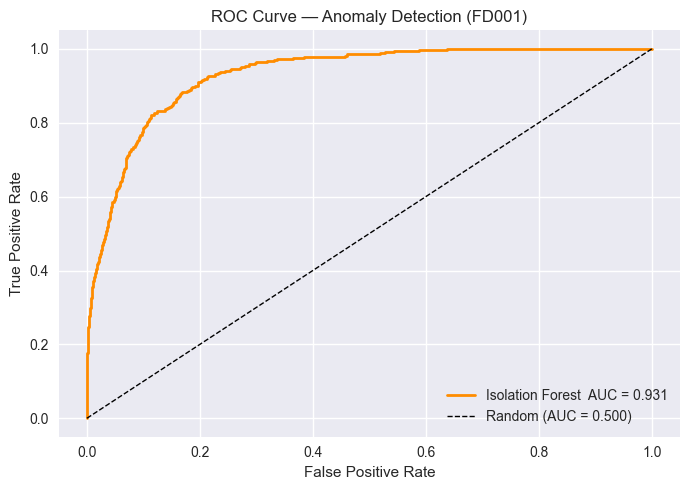

ROC-AUC: 0.9306  ->  PASS (target >= 0.80)


In [40]:
fpr, tpr, _ = roc_curve(y_test, -scores_test)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2,
        label=f'Isolation Forest  AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Anomaly Detection (FD001)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'roc_curve.png'), dpi=120)
plt.show()
print(f'ROC-AUC: {roc_auc:.4f}  ->  {"PASS" if roc_auc >= 0.80 else "FAIL"} (target >= 0.80)')

## 12. Evaluate — Confusion Matrix

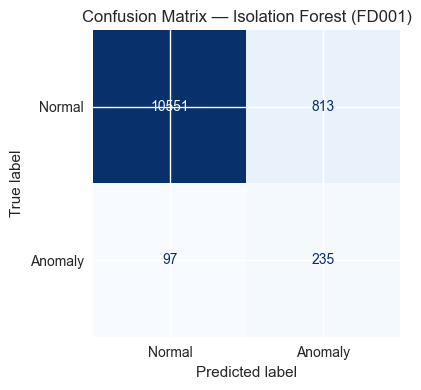

TN=10551  FP=813  FN=97  TP=235
False alarms    (FP): 813  — healthy engines incorrectly flagged
Missed failures (FN): 97  — real anomalies missed  <- keep this low!


In [41]:
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['Normal', 'Anomaly']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Isolation Forest (FD001)')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrix.png'), dpi=120)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'False alarms    (FP): {fp}  — healthy engines incorrectly flagged')
print(f'Missed failures (FN): {fn}  — real anomalies missed  <- keep this low!')

## 13. Save Model & Metadata

In [42]:
model_path   = os.path.join(MODEL_DIR, 'isolation_forest.pkl')
scaler_path  = os.path.join(MODEL_DIR, 'scaler.pkl')
feature_path = os.path.join(MODEL_DIR, 'features.pkl')
meta_path    = os.path.join(MODEL_DIR, 'model_metadata.pkl')

with open(model_path,   'wb') as f: pickle.dump(model, f)
with open(scaler_path,  'wb') as f: pickle.dump(scaler, f)
with open(feature_path, 'wb') as f: pickle.dump(FEATURES, f)

meta = {
    'threshold'        : BEST_THRESHOLD,
    'contamination'    : BEST_CONTAMINATION,
    'features'         : FEATURES,
    'good_sensors'     : GOOD_SENSORS,
    'constant_sensors' : CONSTANT_SENSORS,
    'anomaly_threshold': ANOMALY_THRESHOLD,
    'precision'        : float(prec),
    'recall'           : float(rec),
    'f1'               : float(f1),
    'roc_auc'          : float(roc_auc),
    'dataset'          : 'CMAPSS FD001'
}
with open(meta_path, 'wb') as f: pickle.dump(meta, f)

print(f'Model    -> {model_path}')
print(f'Scaler   -> {scaler_path}')
print(f'Features -> {feature_path}')
print(f'Metadata -> {meta_path}')
print()
print('Final model summary:')
for k in ['contamination','threshold','precision','recall','f1','roc_auc']:
    print(f'  {k:15s}: {meta[k]}')

Model    -> ../edge/ai/models\isolation_forest.pkl
Scaler   -> ../edge/ai/models\scaler.pkl
Features -> ../edge/ai/models\features.pkl
Metadata -> ../edge/ai/models\model_metadata.pkl

Final model summary:
  contamination  : 0.12
  threshold      : 0.022207788708542783
  precision      : 0.22423664122137404
  recall         : 0.7078313253012049
  f1             : 0.34057971014492755
  roc_auc        : 0.9306295933469888


## 14. Inference Sanity Check

In [44]:
with open(model_path,  'rb') as f: loaded_model  = pickle.load(f)
with open(scaler_path, 'rb') as f: loaded_scaler = pickle.load(f)
with open(meta_path,   'rb') as f: loaded_meta   = pickle.load(f)

sample = pd.concat([
    test[test['label'] == 0].sample(3, random_state=42),
    test[test['label'] == 1].sample(3, random_state=42)
])

X_s     = loaded_scaler.transform(sample[loaded_meta['features']])
score_s = loaded_model.decision_function(X_s)
pred_s  = (score_s < loaded_meta['threshold']).astype(int)

result = sample[['engine_id','cycle','rul','label']].copy()
result['predicted']     = pred_s
result['anomaly_score'] = score_s.round(4)
result['correct']       = (result['label'] == result['predicted'])
print('Inference check (3 normal + 3 anomaly):')
print(result.to_string())

Inference check (3 normal + 3 anomaly):
       engine_id  cycle  rul  label  predicted  anomaly_score  correct
101            3     64  125      0          0         0.0508     True
4417          40    103   58      0          0         0.0757     True
200            4     51  125      0          0         0.0520     True
2598          24    183   23      1          1        -0.0169     True
10691         92    147   23      1          1         0.0172     True
3789          34    201    9      1          1        -0.0581     True


## Summary

| Item | Detail |
|---|---|
| Dataset | NASA CMAPSS FD001 |
| Algorithm | Isolation Forest |
| Features | 56 (14 sensors × raw + roll_mean + roll_std + roc) |
| Dropped sensors | s1, s5, s6, s10, s16, s18, s19 (constant) |
| Label strategy | RUL ≤ 30 cycles = anomaly |
| Train/Test split | Separate files (no leakage) |
| Contamination | Auto-selected by F1 on test set |
| Threshold | Tuned for Recall ≥ 0.70 |
| Model | `edge/ai/models/isolation_forest.pkl` |
| Scaler | `edge/ai/models/scaler.pkl` |